# **Data Analysis Assignment 1: Analyzing your own EEG activity from a visual oddball ERP experiment**

**Dataset**: CSV file containing your own Muse EEG activity recorded during a stimulus-evoked ERP experiment (Visual Oddball)

## **Part 1: Visualizing ERPs and interpreting your brain data**

### **Learning goals**

By the end of this notebook, you will be able to 

1. Import and sanity-check real EEG data collected by you.

2. Create event-locked **epochs** around stimulus onset.

3. Compute and plot **average ERPs** for standard vs. deviant stimuli at each electrode.

4. Visualize uncertainty with **SEM shaded error** around ERP traces.

5. Quantify ERP magnitude by finding the maximum value within a **time-window average** (200-400 ms) and summarize with bar plots + SEM errorbars.

### **1) Setup: imports, load data file**

In [2]:
# Let's start by doing our standard imports first! 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

# Optional import 

%matplotlib inline

**File Loading Instructions**

1. Put your CSV file in the same folder as this notebook, or paste the full file path below.

2. If you get an error, check the filename and extension carefully. (On Google Colab, make sure to check where the file is located as well!)

In [3]:
csv_path = "Evoked_Recording_1768357485281.csv" # <-- change this

df = pd.read_csv(csv_path)

df.head()

,Timestamp (ms),Marker,SpaceBar,TouchMarker,ch0_4ms,ch1_4ms,ch2_4ms,ch3_4ms,chAux_4ms,info
0,1768357310754,0,0,0,35.687442,-144.649852,1.081876,22.069594,NaN,[object Object]
1,1768357310754,0,0,0,33.125762,-136.825674,0.813636,20.589709,NaN,[object Object]
2,1768357310755,0,0,0,28.283110,-109.125471,0.291004,18.649555,NaN,[object Object]
3,1768357310755,0,0,0,21.632052,-70.682609,-0.374182,16.624130,NaN,[object Object]
4,1768357310755,0,0,0,13.896149,-32.864876,-1.128680,14.531029,NaN,[object Object]


> **After running the code above, answer QUESTION 1 in your Assignment 1 document.**

### **2) Inspect the data table (sanity checks)**

**Inspecting the raw table** 

Before doing any signal processing, we need to confirm: 

- Which columns correspond to EEG channels (the 4 electrodes) 

- Where the **event markers** live (the information that gives us **stimulus onset times** and **condition labels**)

In [4]:
df.head() 

df.shape, df.columns

((44184, 10),
 Index(['Timestamp (ms)', 'Marker', 'SpaceBar', 'TouchMarker', 'ch0_4ms',
        'ch1_4ms', 'ch2_4ms', 'ch3_4ms', 'chAux_4ms', 'info'],
       dtype='object'))

> **After running the code above, answer QUESTION 2 in your Assignment 1 document.**

### **3) Extract relevant columns from the dataset** 

**Columns we will extract:** 

- Time: <span style="color:green">Timestamp (ms)</span> (our dataset contains absolute time in ms. We will convert to seconds relative to the first sample).

- Condition / event: <span style="color:green">Marker</span> (10 = standard, 20 = deviant).

- Channels: <span style="color:green">ch0_4ms ... ch3_4ms</span>

In [5]:
# Sample rate in Hz 
fs = 250 

# The dataset expresses time in absolute ms. Let's convert to seconds relative from the first sample (i.e., the start of our recording).
time_ms = df["Timestamp (ms)"].to_numpy()
time_s = (time_ms - time_ms[0]) / 1000.0

marker = df["Marker"].to_numpy()

channel_cols = ["ch0_4ms", "ch1_4ms", "ch2_4ms", "ch3_4ms"]
data = df[channel_cols].to_numpy() 

# The shape of the data should be (n_samples, 4)
time_s[:5], data.shape

(array([0.   , 0.   , 0.001, 0.001, 0.001]), (44184, 4))

> **After running the code above, answer QUESTION 3 in your Assignment 1 document.**

### **4) Detect event onsets**

Time to detect when exactly our two types of stimuli (standards and deviants) occurred. We define event onsets as rows where the <span style="color:green">Marker</span> column = 10 for standard stimuli, or 20 for deviant stimuli. 

In [6]:
epoch_start = int(round(fs*0.1))
epoch_end = int(round(fs*0.5))

# event when we go from 0 to 10 or 0 to 20
event_mask = (marker > 0) & (np.roll(marker, 1) == 0)

# boundary constraints 
valid = np.zeros_like(marker, dtype=bool) 
valid[epoch_start : len(data) - epoch_end] = True

event_ix = np.where(event_mask & valid)[0]  # indices of event samples

# Split by condition
std_ix = event_ix[marker[event_ix] == 10]
dev_ix = event_ix[marker[event_ix] == 20]

# output the number of standard and deviant trials found in the data:
len(std_ix), len(dev_ix)

(57, 10)

> **After running the code above, answer QUESTION 4 in your Assignment 1 document.**

### **5) Epoch the data**

Next, we want to epoch the continuous data from [-0.1 to 0.5] seconds. At a sampling frequency of 250 Hz:

- 0.1s = 250 * 0.1 = 25 samples

- 0.5s = 125 samples

Therefore the total epoch length in samples = 25 + 125 + 1 = 151 samples (including time = 0).

In the code below, we will: 

1. In the first code cell, we'll build a variable called <span style="color:green">times</span> that is a long list of numbers (a vector) containing the times of each sample in our epoch

2. In the second cell, we'll slice windows of EEG data around each event index to create epochs of brain activity and then store the epoched data as a 3-D variable, with the dimensions **trials** x **time** x **channels**.

In [7]:
tmin, tmax = -0.1, 0.5
smin = int(round(tmin * fs)) # negative
smax = int(round(tmax * fs)) # positive
sample_offsets = np.arange(smin, smax + 1) # e.g., -25 ... +125
times = sample_offsets / fs

times[0], times[-1], len(times)

(-0.1, 0.5, 151)

In [8]:
# params: 
# - data: (n_samples, n_channels)
# - returns: epochs (n_trials, n_times, n_channels) and kept event indices
def make_epochs(data, event_indices, epoch_start, epoch_end):
    epochs = [] 
    for t in event_indices: 
        if (t - epoch_start >= 0) and (t + epoch_end + 1 <= len(data)): 
            epochs.append(data[t - epoch_start : t + epoch_end + 1, :])
    return np.array(epochs)

epochs_std = make_epochs(data, std_ix, epoch_start, epoch_end)
epochs_dev = make_epochs(data, dev_ix, epoch_start, epoch_end)

epochs_std.shape, epochs_dev.shape

((57, 151, 4), (10, 151, 4))

> **After running the code above, answer QUESTION 5 in the Assignment 1 document.**

### **6) Plot average ERPs**

We will now compute the mean across trials for each stimulus type (standard vs. deviant) and for each electrode.

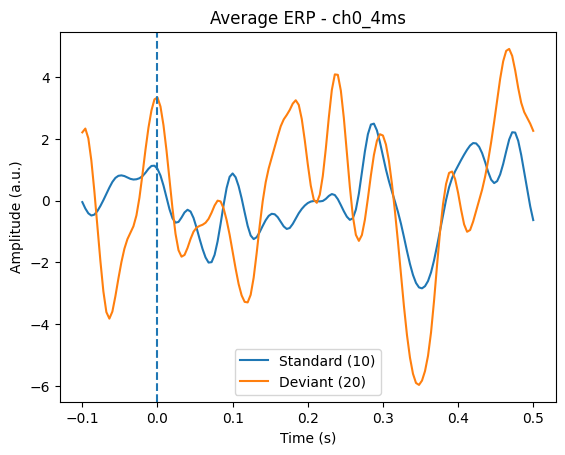

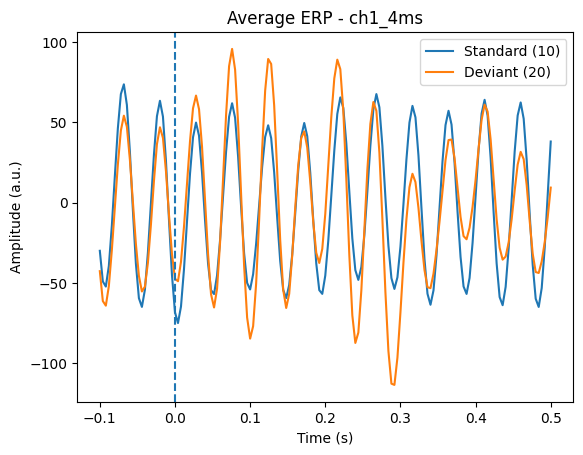

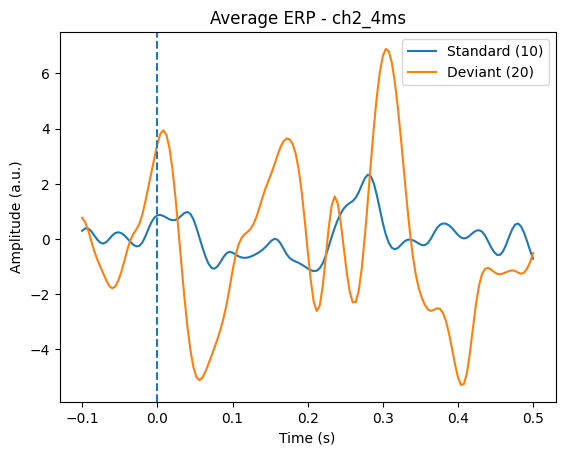

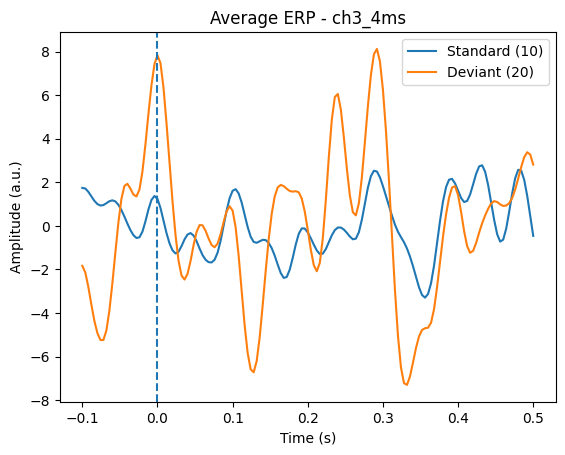

In [9]:
mean_std = epochs_std.mean(axis=0)  # (times, ch)
mean_dev = epochs_dev.mean(axis=0)

for ci, ch in enumerate(channel_cols):
    plt.figure()
    plt.plot(times, mean_std[:, ci], label="Standard (10)")
    plt.plot(times, mean_dev[:, ci], label="Deviant (20)")
    plt.axvline(0, linestyle="--")
    plt.title(f"Average ERP - {ch}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (a.u.)")
    plt.legend()
    plt.show()


> **After running the code above, COPY AND PASTE the figure into QUESTION 6 in your Assignment 1 document and answer the subsequent questions.**

### **7) Add SEM shaded error around traces** 

The standard error of the mean (SEM) at each time-point shows uncertainty in the estimated mean ERP across trials. Let’s add this to our plot of ERPs.

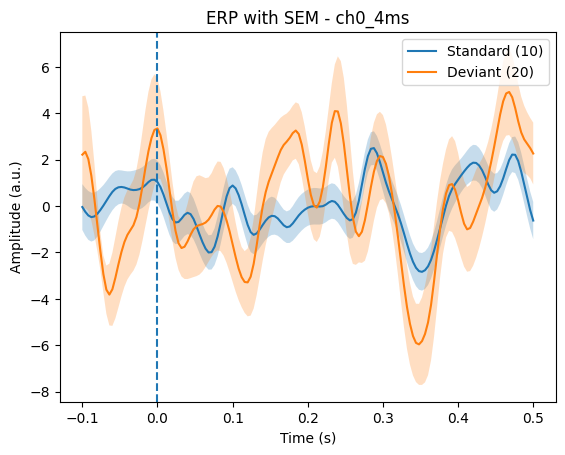

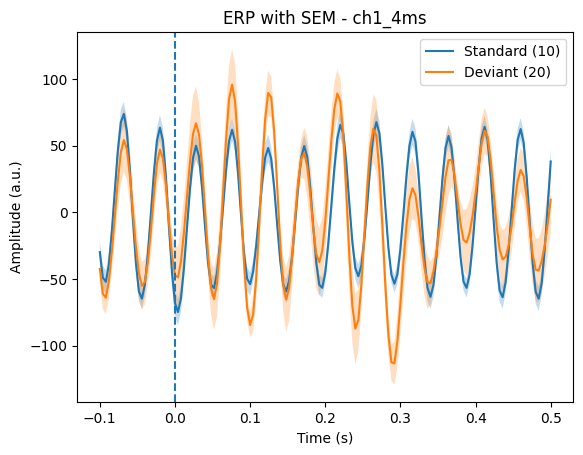

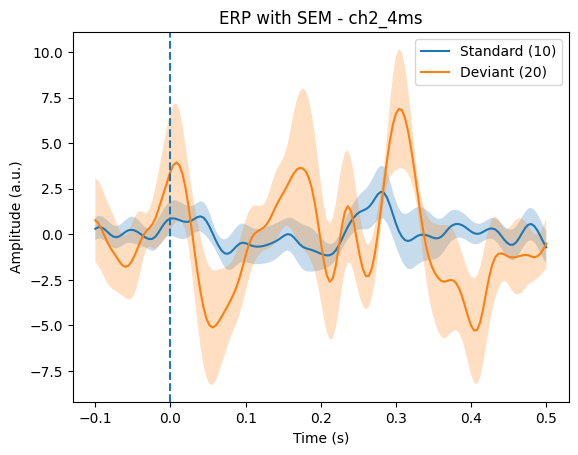

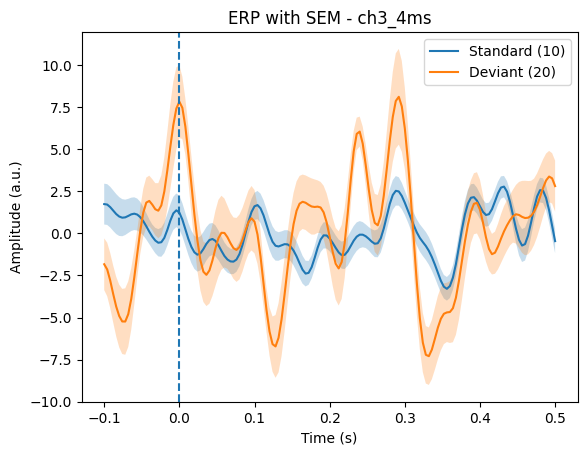

In [10]:
# params: 
# - epochs: (trials, times, ch)
def sem_over_trials(epochs): 
    sd = epochs.std(axis=0, ddof=1)
    n = epochs.shape[0]
    
    return sd/np.sqrt(n)

sem_std = sem_over_trials(epochs_std)
sem_dev = sem_over_trials(epochs_dev)

for ci, ch in enumerate(channel_cols):
    plt.figure()
    for m, s, label in [
        (mean_std[:, ci], sem_std[:, ci], "Standard (10)"),
        (mean_dev[:, ci], sem_dev[:, ci], "Deviant (20)")
    ]:
        plt.plot(times, m, label=label)
        plt.fill_between(times, m - s, m + s, alpha = 0.25)
        
    plt.axvline(0, linestyle="--")
    plt.title(f"ERP with SEM - {ch}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (a.u.)")
    plt.legend()
    plt.show()

> **After running the code above, COPY AND PASTE the figure into QUESTION 7 in your Assignment 1 document and answer the questions.**

### **8) Find maximum response within a time window of 200-400m** 

To quantify the differences you’re seeing in your ERPs of standard vs. deviant stimuli, we will compute a single number per ERP: max amplitude between 0.2–0.4s. We’ll then plot a bar graph with error bars displaying the SEM. 

In [11]:
win_mask = (times >= 0.200) & (times <= 0.400)

max_mean_std = mean_std[win_mask, :].max(axis=0)
max_mean_dev = mean_dev[win_mask, :].max(axis=0)

for ci, ch in enumerate(channel_cols):
    print(f"Channel {ch}: Standard peak = {max_mean_std[ci]:.4f}; Deviant peak = {max_mean_dev[ci]:.4f}")

Channel ch0_4ms: Standard peak = 2.4964; Deviant peak = 4.0909
Channel ch1_4ms: Standard peak = 67.6160; Deviant peak = 89.0335
Channel ch2_4ms: Standard peak = 2.3299; Deviant peak = 6.8884
Channel ch3_4ms: Standard peak = 2.5310; Deviant peak = 8.1191


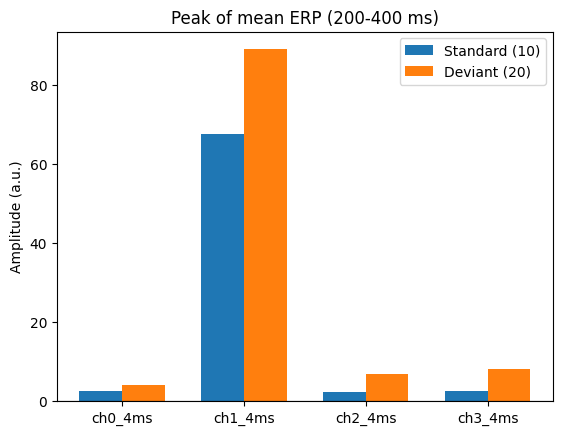

In [12]:
x = np.arange(len(channel_cols))
width = 0.35

plt.figure()
plt.bar(x - width/2, max_mean_std, width, label="Standard (10)")
plt.bar(x + width/2, max_mean_dev, width, label="Deviant (20)")
plt.xticks(x, channel_cols)
plt.axhline(0, color="k", linewidth=0.8)
plt.title("Peak of mean ERP (200-400 ms)")
plt.ylabel("Amplitude (a.u.)")
plt.legend()
plt.show()

> **After running the code above, COPY AND PASTE the figure into QUESTION 7 in your Assignment 1 document and answer the questions.**

## **Part 2: Statistical analysis of ERP-differences using an Analysis of Variance (ANOVA)**

In Part 1, you transformed continuous EEG data into event-related potentials (ERPs), visualized the average responses to standard and deviant stimuli, and quantified the neural response within a theoretically motivated time window (200–400 ms). You examined the waveforms, added measures of variability, and began thinking about how stimulus probability influences brain activity.

In this part of the analysis, we move from **descriptive visualization** to **inferential statistics**. Specifically, we will test whether the **amplitude of the P3 component** (operationalized as the maximum voltage between 200–400 ms post-stimulus for each trial and electrode) differs as a function of **stimulus type** (Standard vs. Deviant) and **electrode location** (four scalp electrodes)

**Learning goals:**
By the end of this part of the assignment, you will: 

1. Implement a 4 x 2 factorial ANOVA in Python
2. Interpret main effects and interactions
3. Quantify and interpret effect size (η<sup>2</sup>)
4. Conduct and interpret post-hoc comparisons (Tukey HSD) 
5. Connect statistical outcomes to neuroscientific theory about the P300 in oddball experimental designs 
6. Critically evaluate the statistical design

### **Step 1) Import libraries for doing statistics in Python**

Before we get started, let's import the statistical libraries we need to use.

In [13]:
import numpy as np
import pandas as pd 
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

> **After running the code above, answer QUESTION 1 in the Assignment document**

### **Step 2) Reshape data into format for Factorial ANOVA**

Earlier in the notebook, we found the maximum amplitude of the data between 200 - 400 ms after stimulus onset. We will use this as an estimate of the P300 amplitude on each trial. Note that rather than averaging across trials within each condition as we did above for visualization purposes, here we will need to preserve single trial data for the ANOVA. 
<br> 

More specifically, the ANOVA requires a table where each row represents one trial and looks like this: 
<br> 

( electrode | stimulus | p3_amplitude )

In [14]:
rows = [] 

# Let's start by filtering 200 - 400 ms of the original data 
# We can reuse the same masking as Part 1 Section 8 
std_window = epochs_std[:, win_mask, :].max(axis=1)
dev_window = epochs_dev[:, win_mask, :].max(axis=1)

# Standard trials 

for trial in range(std_window.shape[0]): 
    for e_idx, electrode in enumerate(channel_cols): 
        rows.append({
            "trial": trial, 
            "electrode": electrode, 
            "stimulus": "standard",
            "p3_amplitude": float(std_window[trial, e_idx])
        })
        
# Deviant trials

for trial in range(dev_window.shape[0]):
    for e_idx, electrode in enumerate(channel_cols):
        rows.append({
            "trial": trial, 
            "electrode": electrode,
            "stimulus": "deviant",
            "p3_amplitude": float(dev_window[trial, e_idx])
        })
        
anova_df = pd.DataFrame(rows)
anova_df.head()

,trial,electrode,stimulus,p3_amplitude
0,0,ch0_4ms,standard,7.705239
1,0,ch1_4ms,standard,115.162194
2,0,ch2_4ms,standard,3.706601
3,0,ch3_4ms,standard,7.681888
4,1,ch0_4ms,standard,9.021710


> **After running the code above, answer QUESTION 2 in the Assignment document**

### **Step 3) Run the 4 x 2 Factorial ANOVA** 

Let's fit our factorial ANOVA model, which has the following format:

#### P3 ~ Electrode + Stimulus-type + Electrode x Stimulus-type

In [15]:
model = smf.ols('p3_amplitude ~ C(electrode) * C(stimulus)', data=anova_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(electrode),901322.060928,3.0,492.473227,6.834185e-107
C(stimulus),53.087796,1.0,0.087020,7.682359e-01
C(electrode):C(stimulus),254.519562,3.0,0.139067,9.365693e-01
Residual,158616.904004,260.0,NaN,NaN


> **BEFORE** running the code above, answer QUESTION 3 in the Assignment document

### **Step 4) Add effect size to the results**

Let's add effect size (eta squared) to our ANOVA table. Recall the formula

$η^2 = SS_{total} / SS_{effect}$

In [16]:
anova_table["eta_sq"] = anova_table["sum_sq"] / anova_table["sum_sq"].sum()
anova_table

,sum_sq,df,F,PR(>F),eta_sq
C(electrode),901322.060928,3.0,492.473227,6.834185e-107,0.850106
C(stimulus),53.087796,1.0,0.087020,7.682359e-01,0.000050
C(electrode):C(stimulus),254.519562,3.0,0.139067,9.365693e-01,0.000240
Residual,158616.904004,260.0,NaN,NaN,0.149604


> **After running the code above, answer QUESTION 4 in the Assignment document**

### **Step 5) Post-Hoc Tests (Tukey HSD)**

Now that we have tested for main effects and interactions using our ANOVA model, we perform post-hoc tests (Tukey HSD) to determine which specific comparisons differ.

#### **A) Post-hoc for Electrode differences**

We will "collapse" the data across stimulus-type, and test whether there are electrode differences for every possible pairwise combination of the 4 electrodes.

In [17]:
tukey_electrode = pairwise_tukeyhsd(
    endog=anova_df["p3_amplitude"],
    groups=anova_df["electrode"],
    alpha=0.05
)

print(tukey_electrode)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1  group2  meandiff p-adj    lower     upper   reject
-----------------------------------------------------------
ch0_4ms ch1_4ms  133.5727    0.0  122.6127  144.5327   True
ch0_4ms ch2_4ms   -1.5779 0.9824  -12.5379    9.3821  False
ch0_4ms ch3_4ms    0.5478 0.9992  -10.4122   11.5078  False
ch1_4ms ch2_4ms -135.1506    0.0 -146.1106 -124.1906   True
ch1_4ms ch3_4ms -133.0249    0.0 -143.9849 -122.0649   True
ch2_4ms ch3_4ms    2.1257 0.9587   -8.8343   13.0857  False
-----------------------------------------------------------


#### **B) Post-hoc for stimulus-type difference**

Similarly, to examine ERP differences between the standard vs deviant, we will "collapse" the data across electrodes to just examine variation based on stimulus-type.

In [18]:
tukey_stimulus = pairwise_tukeyhsd(
    endog=anova_df["p3_amplitude"],
    groups=anova_df["stimulus"],
    alpha=0.05
)
print(tukey_stimulus)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2  meandiff p-adj   lower    upper  reject
--------------------------------------------------------
deviant standard   -1.249 0.9082 -22.5574 20.0594  False
--------------------------------------------------------


> **After running both code cells above (performing post-hoc tests for electrode differences and stimulus-type differences, respectively), answer QUESTION 5 in the Assignment document**

🎉 You’ve finished Assignment 1! Remember to turn in the **Assignment document** not this python notebook!